In [1]:
!git clone https://github.com/HanMoonSub/DeepGuard.git

Cloning into 'DeepGuard'...
remote: Enumerating objects: 3257, done.
remote: Counting objects: 100% (725/725), done.
remote: Compressing objects: 100% (283/283), done.
remote: Total 3257 (delta 547), reused 517 (delta 435), pack-reused 2532 (from 1)
Receiving objects: 100% (3257/3257), 57.90 MiB | 40.30 MiB/s, done.
Resolving deltas: 100% (2025/2025), done.


In [2]:
cd DeepGuard

/content/DeepGuard


In [3]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 139.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.2 MB/s eta 0:00:00


In [5]:
import matplotlib.pyplot as plt

## EigenGradCAM
---


Like EigenCAM but with class discrimination: First principle component of Activations*Grad. Looks like GradCAM, but cleaner

In [6]:
from explainability import EigenGradCAMExplainer

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#### MS-EFF-VIT-B0 (⚡ Fast Model)

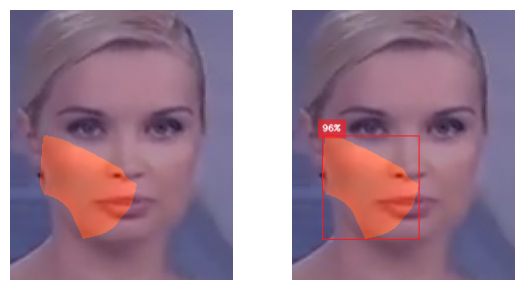

In [17]:
explainer = EigenGradCAMExplainer(
    model_name   = "ms_eff_vit_b0",
    dataset      = "ff++",
    branch_level = "high",
)

heatmap_result = explainer.display_heatmap_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.9,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = True,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = False,  # PCA noise reduction
)

heatmap_bbox_result = explainer.display_heatmap_bbox_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.9,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = True,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = False,  # PCA noise reduction
)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(heatmap_result); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(heatmap_bbox_result); plt.axis("off")
plt.tight_layout(); plt.show()

#### MS-EFF-VIT-B5 (🔥 Pro Model)

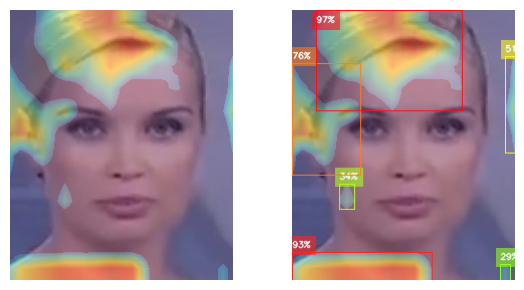

In [27]:
explainer = EigenGradCAMExplainer(
    model_name   = "ms_eff_vit_b5",
    dataset      = "ff++",
    branch_level = "high",
)

heatmap_result = explainer.display_heatmap_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.7,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = True,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = False,  # PCA noise reduction
)

heatmap_bbox_result = explainer.display_heatmap_bbox_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.7,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = True,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = False,  # PCA noise reduction
)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(heatmap_result); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(heatmap_bbox_result); plt.axis("off")
plt.tight_layout(); plt.show()

## GradCamPlusPlus
---

Like GradCAM but uses second order gradients

In [9]:
from explainability import GradCAMPlusPlusExplainer

#### MS-EFF-VIT-B0 (⚡ Fast Model)

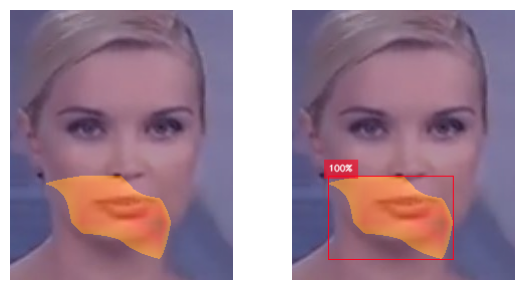

In [35]:
explainer = GradCAMPlusPlusExplainer(
    model_name   = "ms_eff_vit_b0",
    dataset      = "ff++",
    branch_level = "high",
)

heatmap_result = explainer.display_heatmap_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.9,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = False,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = True,  # PCA noise reduction
)

heatmap_bbox_result = explainer.display_heatmap_bbox_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.9,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = False,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = True,  # PCA noise reduction
)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(heatmap_result); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(heatmap_bbox_result); plt.axis("off")
plt.tight_layout(); plt.show()

#### MS-EFF-VIT-B5 (🔥 Pro Model)

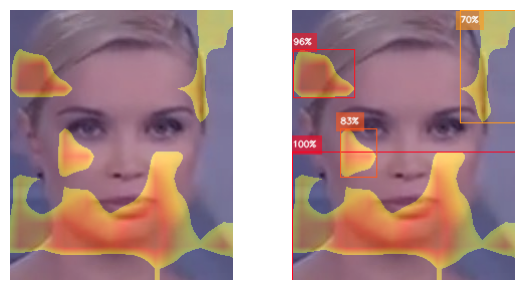

In [42]:
explainer = GradCAMPlusPlusExplainer(
    model_name   = "ms_eff_vit_b5",
    dataset      = "ff++",
    branch_level = "high",
)

heatmap_result = explainer.display_heatmap_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.7,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = False,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = False,  # PCA noise reduction
)

heatmap_bbox_result = explainer.display_heatmap_bbox_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.7,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = False,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = False,  # PCA noise reduction
)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(heatmap_result); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(heatmap_bbox_result); plt.axis("off")
plt.tight_layout(); plt.show()

## XGradCAM
---

Like GradCAM but scale the gradients by the normalized activations

In [12]:
from explainability import XGradCAMExplainer

#### MS-EFF-VIT-B0 (⚡ Fast Model)

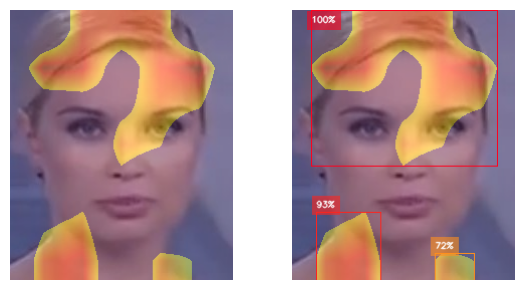

In [50]:
explainer = XGradCAMExplainer(
    model_name   = "ms_eff_vit_b0",
    dataset      = "ff++",
    branch_level = "high",
)

heatmap_result = explainer.display_heatmap_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.7,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = False,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = True,  # PCA noise reduction
)

heatmap_bbox_result = explainer.display_heatmap_bbox_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.7,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = False,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = True,  # PCA noise reduction
)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(heatmap_result); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(heatmap_bbox_result); plt.axis("off")
plt.tight_layout(); plt.show()

#### MS-EFF-VIT-B5 (🔥 Pro Model)

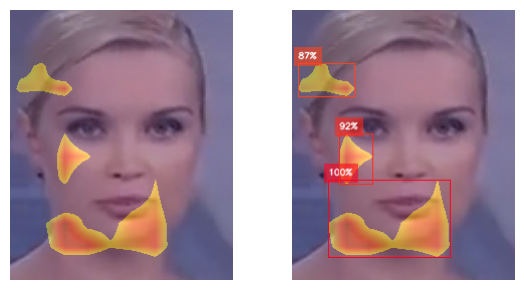

In [53]:
explainer = XGradCAMExplainer(
    model_name   = "ms_eff_vit_b5",
    dataset      = "ff++",
    branch_level = "high",
)

heatmap_result = explainer.display_heatmap_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.9,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = False,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = False,  # PCA noise reduction
)

heatmap_bbox_result = explainer.display_heatmap_bbox_on_image(
    img_path     = "/content/DeepGuard/docs/samples/images/western/western_fake_1.JPG",
    category     = 1,      # 0: Real, 1: Fake
    threshold    = 0.9,    # binarization cutoff (0.5~1.0), or "auto" for Otsu
    image_weight = 0.7,    # 0.0: heatmap only ← → 1.0: original only
    aug_smooth   = False,  # TTA smoothing (not supported on 'pro' models)
    eigen_smooth = False,  # PCA noise reduction
)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(heatmap_result); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(heatmap_bbox_result); plt.axis("off")
plt.tight_layout(); plt.show()